In [ ]:
import os
import json
import time
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score
)

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')
PROJECT_ROOT = Path('/content/drive/MyDrive/TA_SER')


FEATURES_ROOT    = PROJECT_ROOT / 'data' / 'processed' / 'features_v4'
LABEL_ENCODER_FP = PROJECT_ROOT / 'data' / 'processed' / 'label_encoder.json'
MODEL_DIR        = PROJECT_ROOT / 'saved_models' / 'v4'
REPORTS_DIR      = PROJECT_ROOT / 'reports'
TFLITE_DIR       = PROJECT_ROOT / 'saved_models' / 'v4' / 'tflite'

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
TFLITE_DIR.mkdir(parents=True, exist_ok=True)

INPUT_SHAPE = (188, 40)
NUM_CLASSES = 4
SOURCES = ['ravdess', 'emodb', 'tess', 'savee']

MODELS_TO_EVAL = [
    {'name': 'A', 'file': 'model_A_best.h5', 'desc': 'Single-branch baseline'},
    {'name': 'B', 'file': 'model_B_best.keras', 'desc': 'Multi-branch NO dilation'},
    {'name': 'C', 'file': 'model_C_best.keras', 'desc': 'Multi-branch dilated [1,2,4] (v1)'},
    {'name': 'C_v2', 'file': 'model_C_v2_best.keras', 'desc': 'Multi-branch dilated [1,2,3] (WINNER)'},
    {'name': 'C_v3', 'file': 'model_C_v3_best.keras', 'desc': 'Multi-branch dilated [1,2,3] filter=96'},
]

MAIN_MODEL = 'C_v2'

print(f'TF version: {tf.__version__}')
print(f'Models to evaluate: {len(MODELS_TO_EVAL)}')
print(f'MAIN MODEL for deployment: Model {MAIN_MODEL}')


Mounted at /content/drive
TF version: 2.19.0
Models to evaluate: 5
MAIN MODEL for deployment: Model C_v2


In [ ]:
with open(LABEL_ENCODER_FP, 'r') as f:
    label_enc = json.load(f)

LABEL_TO_INT  = label_enc['label_to_int']
INT_TO_LABEL  = {int(k): v for k, v in label_enc['int_to_label'].items()}
TARGET_LABELS = label_enc['target_labels']

print(f'Target labels: {TARGET_LABELS}')
print(f'Label encoding: {LABEL_TO_INT}')

test_per_source = {}
for src in SOURCES:
    X = np.load(FEATURES_ROOT / 'test' / f'X_test_{src}.npy')
    y = np.load(FEATURES_ROOT / 'test' / f'y_test_{src}.npy')
    test_per_source[src] = {'X': X, 'y': y, 'y_oh': to_categorical(y, NUM_CLASSES)}
    print(f'  test_{src}: X={X.shape}  y={y.shape}')

X_test_combined = np.load(FEATURES_ROOT / 'test' / 'X_test_combined.npy')
y_test_combined = np.load(FEATURES_ROOT / 'test' / 'y_test_combined.npy')
sources_test_combined = np.load(FEATURES_ROOT / 'test' / 'sources_test_combined.npy', allow_pickle=True)
y_test_combined_oh = to_categorical(y_test_combined, NUM_CLASSES)

print(f'\n X_test_combined: {X_test_combined.shape}')
print(f'Distribution: {dict(zip(*np.unique(sources_test_combined, return_counts=True)))}')


Target labels: ['angry', 'happy', 'neutral', 'sad']
Label encoding: {'angry': 0, 'happy': 1, 'neutral': 2, 'sad': 3}
  test_ravdess: X=(68, 188, 40)  y=(68,)
  test_emodb: X=(34, 188, 40)  y=(34,)
  test_tess: X=(160, 188, 40)  y=(160,)
  test_savee: X=(30, 188, 40)  y=(30,)

 X_test_combined: (292, 188, 40)
Distribution: {'emodb': np.int64(34), 'ravdess': np.int64(68), 'savee': np.int64(30), 'tess': np.int64(160)}


In [ ]:
def evaluate_model_on_source(model, X, y):

    y_pred_proba = model.predict(X, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    return float(accuracy_score(y, y_pred)), y_pred, y_pred_proba


eval_results = {}

for model_info in MODELS_TO_EVAL:
    name = model_info['name']
    file_path = MODEL_DIR / model_info['file']

    if not file_path.exists():
        print(f' Model {name} not found at {file_path}, skip')
        continue

    print(f'\n Evaluating Model {name} ({model_info["desc"]})')
    print(f'  File: {file_path.name}')

    try:
        model = keras.models.load_model(str(file_path))
    except Exception as e:
        print(f' Load error: {e}')
        continue

    results = {'desc': model_info['desc'], 'params': model.count_params()}

    for src in SOURCES:
        data = test_per_source[src]
        acc, _, _ = evaluate_model_on_source(model, data['X'], data['y'])
        results[f'test_acc_{src}'] = acc
        print(f'  {src:8s} test_acc: {acc:.4f}')

    acc_combined, y_pred_combined, y_proba_combined = evaluate_model_on_source(
        model, X_test_combined, y_test_combined
    )
    results['test_acc_combined'] = acc_combined
    results['y_pred_combined'] = y_pred_combined
    results['y_proba_combined'] = y_proba_combined
    print(f'  {"combined":8s} test_acc: {acc_combined:.4f}')

    eval_results[name] = results

print('\n All models evaluated')



 Evaluating Model A (Single-branch baseline)
  File: model_A_best.h5


  ravdess  test_acc: 0.7647
  emodb    test_acc: 0.9118
  tess     test_acc: 1.0000
  savee    test_acc: 0.8333
  combined test_acc: 0.9178

 Evaluating Model B (Multi-branch NO dilation)
  File: model_B_best.keras
  ravdess  test_acc: 0.6618
  emodb    test_acc: 0.9412
  tess     test_acc: 1.0000
  savee    test_acc: 0.8333
  combined test_acc: 0.8973

 Evaluating Model C (Multi-branch dilated [1,2,4] (v1))
  File: model_C_best.keras
  ravdess  test_acc: 0.7941
  emodb    test_acc: 0.8824
  tess     test_acc: 1.0000
  savee    test_acc: 0.8000
  combined test_acc: 0.9178

 Evaluating Model C_v2 (Multi-branch dilated [1,2,3] (WINNER))
  File: model_C_v2_best.keras
  ravdess  test_acc: 0.8088
  emodb    test_acc: 0.9118
  tess     test_acc: 1.0000
  savee    test_acc: 0.7667
  combined test_acc: 0.9212

 Evaluating Model C_v3 (Multi-branch dilated [1,2,3] filter=96)
  File: model_C_v3_best.keras
  ravdess  test_acc: 0.8088
  emodb    test_acc: 0.9118
  tess     test_acc: 1.0000
  savee 

In [ ]:
rows = []
for name, res in eval_results.items():
    rows.append({
        'Model': f'Model {name}',
        'Params': f'{res["params"]:,}',
        'RAVDESS': f'{res["test_acc_ravdess"]:.4f}',
        'EMODB': f'{res["test_acc_emodb"]:.4f}',
        'TESS': f'{res["test_acc_tess"]:.4f}',
        'SAVEE': f'{res["test_acc_savee"]:.4f}',
        'Combined': f'{res["test_acc_combined"]:.4f}',
    })

df_test = pd.DataFrame(rows)
print('=' * 85)
print('TEST SET ACCURACY — Full Ablation Comparison')
print('=' * 85)
print(df_test.to_string(index=False))
print()

winner = max(eval_results.items(), key=lambda x: x[1]['test_acc_combined'])
print(f' Best test accuracy: Model {winner[0]} ({winner[1]["test_acc_combined"]:.4f})')

test_results_csv = REPORTS_DIR / 'test_results_ablation.csv'
df_test.to_csv(test_results_csv, index=False)
print(f'\n Saved: {test_results_csv}')


TEST SET ACCURACY — Full Ablation Comparison
     Model  Params RAVDESS  EMODB   TESS  SAVEE Combined
   Model A 253,252  0.7647 0.9118 1.0000 0.8333   0.9178
   Model B 130,756  0.6618 0.9412 1.0000 0.8333   0.8973
   Model C 130,756  0.7941 0.8824 1.0000 0.8000   0.9178
Model C_v2 130,756  0.8088 0.9118 1.0000 0.7667   0.9212
Model C_v3 187,300  0.8088 0.9118 1.0000 0.8000   0.9247

 Best test accuracy: Model C_v3 (0.9247)

 Saved: /content/drive/MyDrive/TA_SER/reports/test_results_ablation.csv


In [ ]:
main = eval_results[MAIN_MODEL]

print('=' * 70)
print(f'Per-Class Metrics — Model {MAIN_MODEL} on COMBINED TEST SET')
print('=' * 70)
report = classification_report(
    y_test_combined,
    main['y_pred_combined'],
    target_names=TARGET_LABELS,
    digits=4
)
print(report)

report_dict = classification_report(
    y_test_combined,
    main['y_pred_combined'],
    target_names=TARGET_LABELS,
    output_dict=True
)


Per-Class Metrics — Model C_v2 on COMBINED TEST SET
              precision    recall  f1-score   support

       angry     0.9733    0.9359    0.9542        78
       happy     0.8784    0.8904    0.8844        73
     neutral     0.9067    0.9855    0.9444        69
         sad     0.9265    0.8750    0.9000        72

    accuracy                         0.9212       292
   macro avg     0.9212    0.9217    0.9208       292
weighted avg     0.9223    0.9212    0.9211       292



In [ ]:
main_model = keras.models.load_model(str(MODEL_DIR / f'model_{MAIN_MODEL}_best.keras'))

per_source_reports = {}

for src in SOURCES:
    data = test_per_source[src]
    y_pred_src = np.argmax(main_model.predict(data['X'], verbose=0), axis=1)

    p, r, f, s = precision_recall_fscore_support(
        data['y'], y_pred_src,
        labels=list(range(NUM_CLASSES)),
        zero_division=0
    )

    src_report = {
        label: {
            'precision': float(p[i]),
            'recall': float(r[i]),
            'f1': float(f[i]),
            'support': int(s[i])
        }
        for i, label in enumerate(TARGET_LABELS)
    }
    per_source_reports[src] = src_report

    print(f'\n {src.upper()}')
    print(f'  {"Class":10s} {"Precision":>10s} {"Recall":>10s} {"F1":>10s} {"Support":>10s}')
    for i, label in enumerate(TARGET_LABELS):
        print(f'  {label:10s} {p[i]:>10.4f} {r[i]:>10.4f} {f[i]:>10.4f} {int(s[i]):>10d}')



 RAVDESS
  Class       Precision     Recall         F1    Support
  angry          0.9444     0.8947     0.9189         19
  happy          0.7143     0.7500     0.7317         20
  neutral        0.8889     0.8889     0.8889          9
  sad            0.7500     0.7500     0.7500         20

 EMODB
  Class       Precision     Recall         F1    Support
  angry          0.9231     0.9231     0.9231         13
  happy          0.8333     0.7143     0.7692          7
  neutral        0.8889     1.0000     0.9412          8
  sad            1.0000     1.0000     1.0000          6

 TESS
  Class       Precision     Recall         F1    Support
  angry          1.0000     1.0000     1.0000         40
  happy          1.0000     1.0000     1.0000         40
  neutral        1.0000     1.0000     1.0000         40
  sad            1.0000     1.0000     1.0000         40

 SAVEE
  Class       Precision     Recall         F1    Support
  angry          1.0000     0.6667     0.8000          

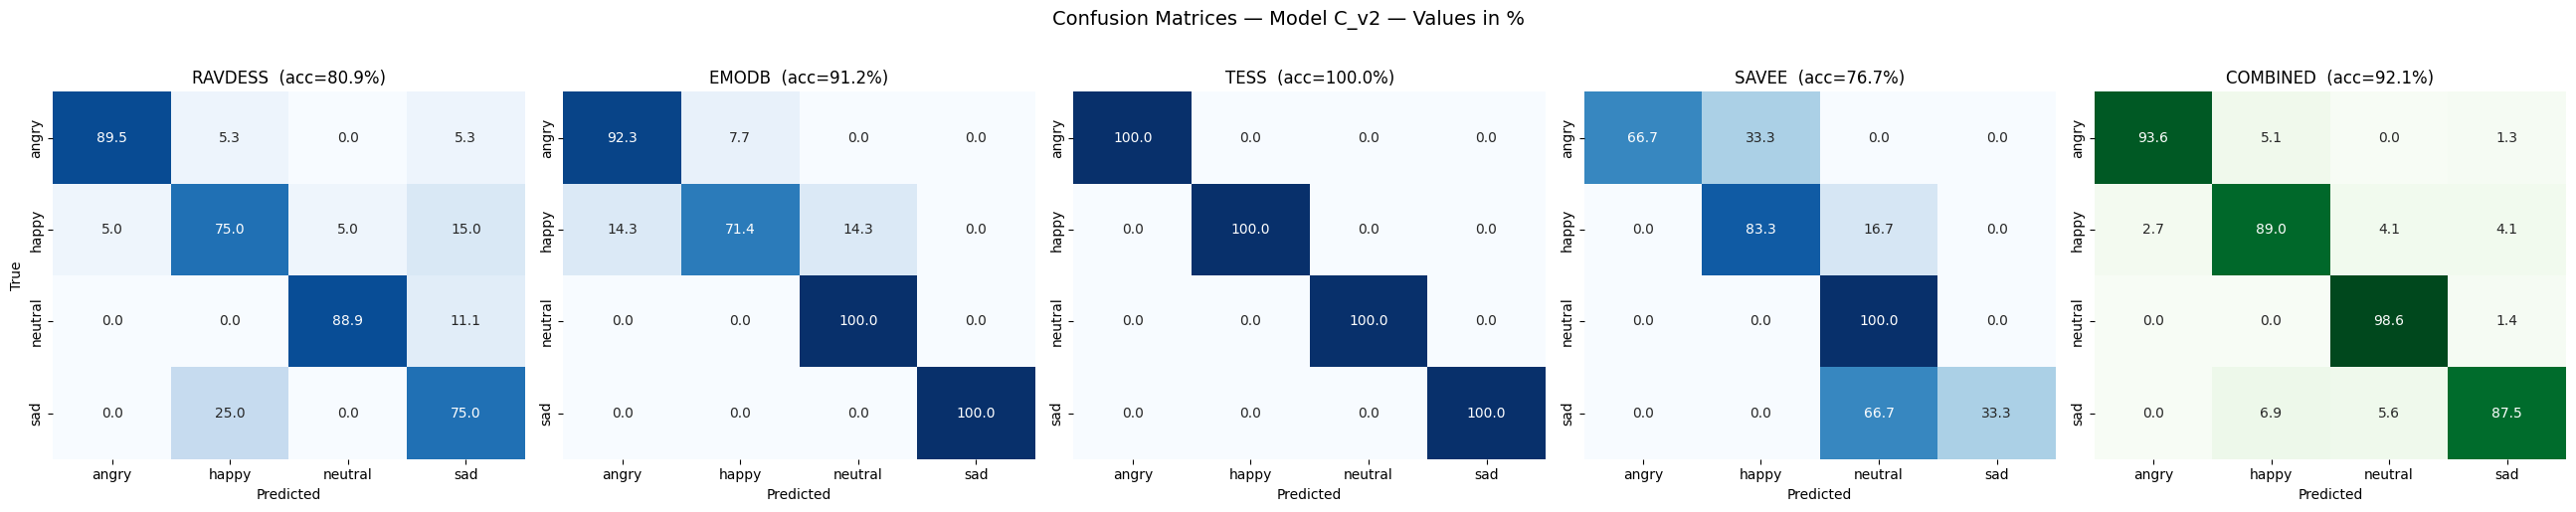


 Saved: /content/drive/MyDrive/TA_SER/reports/confusion_matrix_C_v2.png


In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(26, 5))

for idx, src in enumerate(SOURCES):
    data = test_per_source[src]
    y_pred_src = np.argmax(main_model.predict(data['X'], verbose=0), axis=1)

    cm = confusion_matrix(data['y'], y_pred_src, labels=list(range(NUM_CLASSES)))
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(
        cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[idx],
        xticklabels=TARGET_LABELS, yticklabels=TARGET_LABELS,
        cbar=False, vmin=0, vmax=100
    )
    acc = np.trace(cm) / np.sum(cm) * 100
    axes[idx].set_title(f'{src.upper()}  (acc={acc:.1f}%)')
    axes[idx].set_xlabel('Predicted')
    if idx == 0:
        axes[idx].set_ylabel('True')

cm_comb = confusion_matrix(y_test_combined, main['y_pred_combined'], labels=list(range(NUM_CLASSES)))
cm_comb_pct = cm_comb.astype(float) / cm_comb.sum(axis=1, keepdims=True) * 100
sns.heatmap(
    cm_comb_pct, annot=True, fmt='.1f', cmap='Greens', ax=axes[4],
    xticklabels=TARGET_LABELS, yticklabels=TARGET_LABELS,
    cbar=False, vmin=0, vmax=100
)
acc_comb = np.trace(cm_comb) / np.sum(cm_comb) * 100
axes[4].set_title(f'COMBINED  (acc={acc_comb:.1f}%)')
axes[4].set_xlabel('Predicted')

plt.suptitle(f'Confusion Matrices — Model {MAIN_MODEL} — Values in %', fontsize=14, y=1.02)
plt.tight_layout()
cm_plot_path = REPORTS_DIR / f'confusion_matrix_{MAIN_MODEL}.png'
plt.savefig(cm_plot_path, dpi=100, bbox_inches='tight')
plt.show()

print(f'\n Saved: {cm_plot_path}')


In [ ]:
def delta(a, b):
    return (b - a) * 100

print('=' * 70)
print('ABLATION TIER ANALYSIS (Test Set)')
print('=' * 70)

if all(m in eval_results for m in ['A', 'B', 'C', 'C_v2']):
    a_acc = eval_results['A']['test_acc_combined']
    b_acc = eval_results['B']['test_acc_combined']
    c_acc = eval_results['C']['test_acc_combined']
    cv2_acc = eval_results['C_v2']['test_acc_combined']

    print(f' TIER 1: Kontribusi Multi-Branch')
    print(f' Model A (single-branch, 253K params): {a_acc:.4f}')
    print(f' Model B (multi-branch, 131K params):  {b_acc:.4f}')
    print(f' {delta(a_acc, b_acc):+.2f}%')
    if b_acc >= a_acc:
        print(f' -> Multi-branch dengan config ini BERHASIL meningkatkan akurasi')
    else:
        print(f' -> Multi-branch naive TIDAK cukup (dilation config matters)')

    print(f' TIER 2: Kontribusi Naive Dilation')
    print(f' Model B (dilation [1,1,1]): {b_acc:.4f}')
    print(f' Model C (dilation [1,2,4]): {c_acc:.4f}')
    print(f' {delta(b_acc, c_acc):+.2f}%')
    if c_acc >= b_acc:
        print(f'  -> Dilation [1,2,4] membantu')
    else:
        print(f'  -> Dilation [1,2,4] TERLALU AGRESIF untuk task ini')

    print(f' TIER 3: Kontribusi Refined Dilation (KUNCI)')
    print(f' Model C v1 (dilation [1,2,4], padding causal): {c_acc:.4f}')
    print(f' Model C v2 (dilation [1,2,3], padding same):  {cv2_acc:.4f}')
    print(f' {delta(c_acc, cv2_acc):+.2f}%')

    print(f' FINAL: C_v2 vs A (head-to-head)')
    print(f' Model A (baseline): {a_acc:.4f}  (params 253K)')
    print(f' Model C_v2 (main):  {cv2_acc:.4f}  (params 131K)')
    print(f' acc = {delta(a_acc, cv2_acc):+.2f}%')
    print(f' params = {(253252 - 130756)/253252*100:.1f}% lebih hemat')

print(f' EMODB-Specific: Dilation Fix Impact')
if 'C' in eval_results and 'C_v2' in eval_results:
    c_emodb = eval_results['C']['test_acc_emodb']
    cv2_emodb = eval_results['C_v2']['test_acc_emodb']
    print(f' Model C v1 EMODB:  {c_emodb:.4f}')
    print(f' Model C v2 EMODB:  {cv2_emodb:.4f}')
    print(f' {delta(c_emodb, cv2_emodb):+.2f}%')


ABLATION TIER ANALYSIS (Test Set)
 TIER 1: Kontribusi Multi-Branch
 Model A (single-branch, 253K params): 0.9178
 Model B (multi-branch, 131K params):  0.8973
 -2.05%
 -> Multi-branch naive TIDAK cukup (dilation config matters)
 TIER 2: Kontribusi Naive Dilation
 Model B (dilation [1,1,1]): 0.8973
 Model C (dilation [1,2,4]): 0.9178
 +2.05%
  -> Dilation [1,2,4] membantu
 TIER 3: Kontribusi Refined Dilation (KUNCI)
 Model C v1 (dilation [1,2,4], padding causal): 0.9178
 Model C v2 (dilation [1,2,3], padding same):  0.9212
 +0.34%
 FINAL: C_v2 vs A (head-to-head)
 Model A (baseline): 0.9178  (params 253K)
 Model C_v2 (main):  0.9212  (params 131K)
 acc = +0.34%
 params = 48.4% lebih hemat
 EMODB-Specific: Dilation Fix Impact
 Model C v1 EMODB:  0.8824
 Model C v2 EMODB:  0.9118
 +2.94%


In [ ]:
ablation_export = []
for name, res in eval_results.items():
    ablation_export.append({
        'model': name,
        'description': res['desc'],
        'params': res['params'],
        'test_acc_ravdess': round(res['test_acc_ravdess'], 4),
        'test_acc_emodb': round(res['test_acc_emodb'], 4),
        'test_acc_tess': round(res['test_acc_tess'], 4),
        'test_acc_savee': round(res['test_acc_savee'], 4),
        'test_acc_combined': round(res['test_acc_combined'], 4),
    })

ablation_summary = {
    'main_model': MAIN_MODEL,
    'main_model_justification': 'Highest test accuracy with 48% fewer params than baseline Model A',
    'ablation_results': ablation_export,
    'per_class_metrics_main': {
        label: {
            'precision': round(report_dict[label]['precision'], 4),
            'recall': round(report_dict[label]['recall'], 4),
            'f1-score': round(report_dict[label]['f1-score'], 4),
            'support': int(report_dict[label]['support'])
        }
        for label in TARGET_LABELS
    },
    'per_source_per_class_metrics_main': per_source_reports,
    'notes': {
        'tier_1': 'Multi-branch vs single-branch',
        'tier_2': 'Naive dilation [1,2,4] impact',
        'tier_3': 'Refined dilation [1,2,3] with padding=same (Mustaqeem 2021-inspired)',
    }
}

summary_path = REPORTS_DIR / 'ablation_summary_full.json'
with open(summary_path, 'w') as f:
    json.dump(ablation_summary, f, indent=2)

print(f' Saved: {summary_path}')

df_ablation = pd.DataFrame(ablation_export)
ablation_csv = REPORTS_DIR / 'ablation_summary_full.csv'
df_ablation.to_csv(ablation_csv, index=False)
print(f' Saved: {ablation_csv}')
print('\n FINAL ABLATION TABL ')
print(df_ablation.to_string(index=False))


 Saved: /content/drive/MyDrive/TA_SER/reports/ablation_summary_full.json
 Saved: /content/drive/MyDrive/TA_SER/reports/ablation_summary_full.csv

 FINAL ABLATION TABL 
model                            description  params  test_acc_ravdess  test_acc_emodb  test_acc_tess  test_acc_savee  test_acc_combined
    A                 Single-branch baseline  253252            0.7647          0.9118            1.0          0.8333             0.9178
    B               Multi-branch NO dilation  130756            0.6618          0.9412            1.0          0.8333             0.8973
    C      Multi-branch dilated [1,2,4] (v1)  130756            0.7941          0.8824            1.0          0.8000             0.9178
 C_v2  Multi-branch dilated [1,2,3] (WINNER)  130756            0.8088          0.9118            1.0          0.7667             0.9212
 C_v3 Multi-branch dilated [1,2,3] filter=96  187300            0.8088          0.9118            1.0          0.8000             0.9247


In [ ]:
main_model = keras.models.load_model(str(MODEL_DIR / f'model_{MAIN_MODEL}_best.keras'))

converter_fp32 = tf.lite.TFLiteConverter.from_keras_model(main_model)
tflite_fp32 = converter_fp32.convert()

tflite_fp32_path = TFLITE_DIR / f'model_{MAIN_MODEL}_fp32.tflite'
with open(tflite_fp32_path, 'wb') as f:
    f.write(tflite_fp32)

size_fp32_kb = len(tflite_fp32) / 1024
print(f' TFLite FP32 saved: {tflite_fp32_path.name}')
print(f' Size: {size_fp32_kb:.1f} KB ({size_fp32_kb/1024:.2f} MB)')


Saved artifact at '/tmp/tmprhriu4de'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 188, 40), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133578584666960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133578584667152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133578584666384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133578584664848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133578584661392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133578584664464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133578584669072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133578584669264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133578584668688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133578584668880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133578584668304: TensorSp

In [ ]:
X_train = np.load(FEATURES_ROOT / 'train' / 'X_train.npy')

def representative_dataset_gen():

    np.random.seed(42)
    indices = np.random.choice(len(X_train), 100, replace=False)
    for idx in indices:
        sample = X_train[idx:idx+1].astype(np.float32)
        yield [sample]

converter_int8 = tf.lite.TFLiteConverter.from_keras_model(main_model)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_dataset_gen

converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type = tf.int8
converter_int8.inference_output_type = tf.int8

try:
    tflite_int8 = converter_int8.convert()
    tflite_int8_path = TFLITE_DIR / f'model_{MAIN_MODEL}_int8.tflite'
    with open(tflite_int8_path, 'wb') as f:
        f.write(tflite_int8)
    size_int8_kb = len(tflite_int8) / 1024
    int8_success = True
    print(f' TFLite INT8 saved: {tflite_int8_path.name}')
    print(f' Size: {size_int8_kb:.1f} KB ({size_int8_kb/1024:.2f} MB)')
    print(f' Compression vs FP32: {size_fp32_kb/size_int8_kb:.2f}x smaller')
except Exception as e:
    print(f' Full INT8 failed: {e}')
    print(f' Fallback to DYNAMIC RANGE quantization (weights INT8, activations FP32)...')

    converter_dyn = tf.lite.TFLiteConverter.from_keras_model(main_model)
    converter_dyn.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_int8 = converter_dyn.convert()
    tflite_int8_path = TFLITE_DIR / f'model_{MAIN_MODEL}_dynrange.tflite'
    with open(tflite_int8_path, 'wb') as f:
        f.write(tflite_int8)
    size_int8_kb = len(tflite_int8) / 1024
    int8_success = False
    print(f' TFLite Dynamic Range saved: {tflite_int8_path.name}')
    print(f' Size: {size_int8_kb:.1f} KB')


Saved artifact at '/tmp/tmp32iddmsw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 188, 40), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133578584666960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133578584667152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133578584666384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133578584664848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133578584661392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133578584664464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133578584669072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133578584669264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133578584668688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133578584668880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133578584668304: TensorSp

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


 TFLite INT8 saved: model_C_v2_int8.tflite
 Size: 151.2 KB (0.15 MB)
 Compression vs FP32: 3.43x smaller


In [ ]:
def evaluate_tflite(tflite_path, X, y, is_int8=False):

    interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    correct = 0
    for i in range(len(X)):
        sample = X[i:i+1]
        if is_int8 and input_details[0]['dtype'] == np.int8:

            input_scale, input_zero_point = input_details[0]['quantization']
            sample = (sample / input_scale + input_zero_point).astype(np.int8)
        else:
            sample = sample.astype(np.float32)

        interpreter.set_tensor(input_details[0]['index'], sample)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])

        if is_int8 and output_details[0]['dtype'] == np.int8:
            output_scale, output_zero_point = output_details[0]['quantization']
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = np.argmax(output, axis=1)[0]
        if pred == y[i]:
            correct += 1

    return correct / len(X)


print('=' * 60)
print('TFLite Accuracy Validation (on combined test set)')
print('=' * 60)
orig_acc = main['test_acc_combined']
print(f'\n Original Keras model: {orig_acc:.4f}')

acc_fp32 = evaluate_tflite(tflite_fp32_path, X_test_combined, y_test_combined, is_int8=False)
print(f'TFLite FP32:          {acc_fp32:.4f}  ({(acc_fp32 - orig_acc)*100:+.2f}%)')

acc_int8 = evaluate_tflite(tflite_int8_path, X_test_combined, y_test_combined, is_int8=int8_success)
label_int8 = 'TFLite INT8' if int8_success else 'TFLite DynRange'
print(f'{label_int8:21s} {acc_int8:.4f}  ({(acc_int8 - orig_acc)*100:+.2f}%)')

# Decision: which quantization to deploy?
print('\n  DEPLOYMENT DECISIOn ')
if abs(acc_int8 - orig_acc) < 0.02:  # <2% drop
    print(f' {label_int8} acceptable (drop <2%), RECOMMENDED for RPi deployment')
else:
    print(f' {label_int8} has >2% accuracy drop, consider FP32 instead')


TFLite Accuracy Validation (on combined test set)

 Original Keras model: 0.9212


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


TFLite FP32:          0.9212  (+0.00%)
TFLite INT8           0.9110  (-1.03%)

  DEPLOYMENT DECISIOn 
 TFLite INT8 acceptable (drop <2%), RECOMMENDED for RPi deployment


In [ ]:
def benchmark_latency(tflite_path, X_sample, is_int8=False, n_runs=100):

    interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    sample = X_sample[0:1]
    if is_int8 and input_details[0]['dtype'] == np.int8:
        input_scale, input_zero_point = input_details[0]['quantization']
        sample = (sample / input_scale + input_zero_point).astype(np.int8)
    else:
        sample = sample.astype(np.float32)

    for _ in range(10):
        interpreter.set_tensor(input_details[0]['index'], sample)
        interpreter.invoke()

    latencies = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        interpreter.set_tensor(input_details[0]['index'], sample)
        interpreter.invoke()
        _ = interpreter.get_tensor(output_details[0]['index'])
        latencies.append((time.perf_counter() - t0) * 1000)  # ms

    return float(np.mean(latencies)), float(np.std(latencies))

print('Benchmarking Keras model...')
keras_latencies = []
for _ in range(10):
    _ = main_model.predict(X_test_combined[0:1], verbose=0)
for _ in range(50):
    t0 = time.perf_counter()
    _ = main_model.predict(X_test_combined[0:1], verbose=0)
    keras_latencies.append((time.perf_counter() - t0) * 1000)
keras_mean = np.mean(keras_latencies)
keras_std = np.std(keras_latencies)

print('Benchmarking TFLite FP32...')
fp32_mean, fp32_std = benchmark_latency(tflite_fp32_path, X_test_combined, is_int8=False)

print('Benchmarking TFLite INT8/DynRange...')
int8_mean, int8_std = benchmark_latency(tflite_int8_path, X_test_combined, is_int8=int8_success)

print('\n' + '=' * 75)
print('DEPLOYMENT READINESS REPORT (Colab CPU benchmark)')
print('=' * 75)
print(f'{"Format":25s} {"Size (KB)":>12s} {"Latency (ms)":>15s} {"Accuracy":>12s}')
print('-' * 75)
print(f'{"Keras (original)":25s} {"N/A":>12s} {keras_mean:>10.2f} ± {keras_std:.1f} {orig_acc:>11.4f}')
print(f'{"TFLite FP32":25s} {size_fp32_kb:>12.1f} {fp32_mean:>10.2f} ± {fp32_std:.1f} {acc_fp32:>11.4f}')
label_int8_lat = 'TFLite INT8' if int8_success else 'TFLite Dynamic Range'
print(f'{label_int8_lat:25s} {size_int8_kb:>12.1f} {int8_mean:>10.2f} ± {int8_std:.1f} {acc_int8:>11.4f}')
print()

rpi_estimate = int8_mean * 2.5
print(f'Estimasi RPi 4B (2.5x factor): ~{rpi_estimate:.1f} ms')
target = 100
if rpi_estimate < target:
    print(f' Estimasi di bawah target real-time ({target} ms) — VIABLE untuk deployment')
else:
    print(f' Estimasi di atas target real-time ({target} ms) — benchmark actual RPi')


Benchmarking Keras model...
Benchmarking TFLite FP32...
Benchmarking TFLite INT8/DynRange...

DEPLOYMENT READINESS REPORT (Colab CPU benchmark)
Format                       Size (KB)    Latency (ms)     Accuracy
---------------------------------------------------------------------------
Keras (original)                   N/A     129.66 ± 106.7      0.9212
TFLite FP32                      517.8       0.44 ± 0.0      0.9212
TFLite INT8                      151.2       0.56 ± 0.1      0.9110

Estimasi RPi 4B (2.5x factor): ~1.4 ms
 Estimasi di bawah target real-time (100 ms) — VIABLE untuk deployment


In [ ]:
deployment_report = {
    'main_model': MAIN_MODEL,
    'test_accuracy': {
        'combined': orig_acc,
        'ravdess': main['test_acc_ravdess'],
        'emodb': main['test_acc_emodb'],
        'tess': main['test_acc_tess'],
        'savee': main['test_acc_savee'],
    },
    'formats': {
        'keras_original': {
            'file': f'model_{MAIN_MODEL}_best.keras',
            'latency_ms_mean': keras_mean,
            'latency_ms_std': keras_std,
            'accuracy': orig_acc,
        },
        'tflite_fp32': {
            'file': tflite_fp32_path.name,
            'size_kb': size_fp32_kb,
            'latency_ms_mean': fp32_mean,
            'latency_ms_std': fp32_std,
            'accuracy': acc_fp32,
        },
        'tflite_quantized': {
            'file': tflite_int8_path.name,
            'quantization_type': 'INT8' if int8_success else 'Dynamic Range',
            'size_kb': size_int8_kb,
            'latency_ms_mean': int8_mean,
            'latency_ms_std': int8_std,
            'accuracy': acc_int8,
        },
    },
    'rpi_estimation': {
        'quantized_latency_ms': rpi_estimate,
        'target_latency_ms': 100,
        'viable': rpi_estimate < 100,
        'note': '2.5x slower than Colab CPU (rough estimate), need actual RPi benchmark',
    },
    'deployment_recommendation': (
        f'Deploy TFLite {"INT8" if int8_success else "Dynamic Range"} ke RPi 4B '
        f'(size {size_int8_kb:.1f}KB, accuracy {acc_int8:.4f})'
    ),
}

report_path = REPORTS_DIR / 'deployment_report.json'
with open(report_path, 'w') as f:
    json.dump(deployment_report, f, indent=2)

print(f' Saved: {report_path}')
print(f'\n {deployment_report["deployment_recommendation"]}')


 Saved: /content/drive/MyDrive/TA_SER/reports/deployment_report.json

 Deploy TFLite INT8 ke RPi 4B (size 151.2KB, accuracy 0.9110)


In [ ]:
PROJECT_ROOT  = Path('/content/drive/MyDrive/TA_SER')
FEATURES_ROOT = PROJECT_ROOT / 'data' / 'processed' / 'features_v4'
MODEL_DIR     = PROJECT_ROOT / 'saved_models' / 'v4'
REPORTS_DIR   = PROJECT_ROOT / 'reports'

NUM_CLASSES   = 4
TARGET_LABELS = ['angry', 'happy', 'neutral', 'sad']

# Load test data
X_test_combined     = np.load(FEATURES_ROOT / 'test' / 'X_test_combined.npy')
y_test_combined     = np.load(FEATURES_ROOT / 'test' / 'y_test_combined.npy')

# Load model & predict
main_model = keras.models.load_model(str(MODEL_DIR / 'model_C_v2_best.keras'))
y_pred     = np.argmax(main_model.predict(X_test_combined, verbose=0), axis=1)

main = {'y_pred_combined': y_pred}

print('Variables loaded!')
print(f'X_test: {X_test_combined.shape}, y_test: {y_test_combined.shape}')

Variables loaded!
X_test: (292, 188, 40), y_test: (292,)


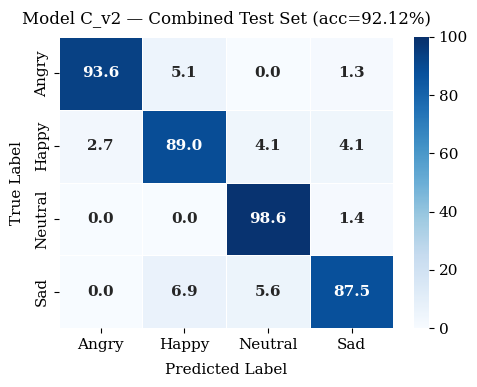

Saved: /content/drive/MyDrive/TA_SER/reports/paper_confusion_matrix.png


In [ ]:
import matplotlib
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})

fig, ax = plt.subplots(figsize=(5, 4))

cm = confusion_matrix(y_test_combined, main['y_pred_combined'],
                      labels=list(range(NUM_CLASSES)))
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

sns.heatmap(
    cm_pct,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    ax=ax,
    xticklabels=['Angry', 'Happy', 'Neutral', 'Sad'],
    yticklabels=['Angry', 'Happy', 'Neutral', 'Sad'],
    cbar=True,
    vmin=0, vmax=100,
    linewidths=0.5,
    annot_kws={'size': 11, 'weight': 'bold'}
)

ax.set_xlabel('Predicted Label', fontsize=11, labelpad=8)
ax.set_ylabel('True Label', fontsize=11, labelpad=8)
ax.set_title('Model C_v2 — Combined Test Set (acc=92.12%)', fontsize=12, pad=10)

plt.tight_layout()

out_path = REPORTS_DIR / 'paper_confusion_matrix.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {out_path}')